U Net


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [2]:
class CircleDataset(Dataset):
    def __init__(self, size=200):
        self.size = size

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        img = np.zeros((128,128))
        mask = np.zeros((128,128))

        x, y = np.random.randint(30,98,2)
        r = np.random.randint(10,25)

        for i in range(128):
            for j in range(128):
                if (i-x)**2 + (j-y)**2 <= r**2:
                    img[i,j] = 1
                    mask[i,j] = 1

        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

dataset = CircleDataset()
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        bottleneck = self.bottleneck(p2)

        up1 = self.up1(bottleneck)
        concat1 = torch.cat([up1, d2], dim=1)
        c1 = self.conv1(concat1)

        up2 = self.up2(c1)
        concat2 = torch.cat([up2, d1], dim=1)
        c2 = self.conv2(concat2)

        return torch.sigmoid(self.final(c2))


model = UNet()

In [ ]:
imgs, masks = next(iter(dataloader))
preds = model(imgs)

plt.figure(figsize=(12,4))

for i in range(3):
    plt.subplot(3,3,i+1)
    plt.imshow(imgs[i][0], cmap='gray')
    plt.title("Input")
    plt.axis("off")

    plt.subplot(3,3,i+4)
    plt.imshow(masks[i][0], cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(3,3,i+7)
    plt.imshow(preds[i][0].detach(), cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.show()

Hierarchical RAG

In [6]:
!pip install sentence-transformers faiss-cpu transformers --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.2 MB/s eta 0:00:00


In [7]:
documents = {
    "Machine Learning": """
    Machine learning is a subset of AI.
    It includes supervised learning, unsupervised learning, and reinforcement learning.
    Algorithms learn patterns from data.
    """,

    "Deep Learning": """
    Deep learning is a subset of machine learning.
    It uses neural networks with many layers.
    CNNs and RNNs are popular deep learning models.
    """,

    "Computer Vision": """
    Computer vision enables machines to interpret images.
    It uses CNNs for image classification and segmentation.
    Applications include object detection and medical imaging.
    """
}

In [8]:
def split_into_chunks(text):
    return [sent.strip() for sent in text.split(".") if sent.strip()]

doc_chunks = {}

for title, content in documents.items():
    doc_chunks[title] = split_into_chunks(content)

In [9]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

embedder = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
doc_titles = list(documents.keys())
doc_embeddings = embedder.encode(doc_titles)

# Create FAISS index
dimension = doc_embeddings.shape[1]
doc_index = faiss.IndexFlatL2(dimension)
doc_index.add(np.array(doc_embeddings))

In [11]:
chunk_data = []
chunk_texts = []

for title, chunks in doc_chunks.items():
    for chunk in chunks:
        chunk_data.append((title, chunk))
        chunk_texts.append(chunk)

chunk_embeddings = embedder.encode(chunk_texts)

chunk_index = faiss.IndexFlatL2(dimension)
chunk_index.add(np.array(chunk_embeddings))

In [12]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

def hierarchical_rag(query):
    # ---- Level 1: Document Retrieval ----
    query_embedding = embedder.encode([query])
    _, doc_ids = doc_index.search(np.array(query_embedding), k=1)
    best_doc = doc_titles[doc_ids[0][0]]

    # ---- Level 2: Chunk Retrieval ----
    _, chunk_ids = chunk_index.search(np.array(query_embedding), k=2)
    selected_chunks = []

    for idx in chunk_ids[0]:
        title, chunk = chunk_data[idx]
        if title == best_doc:
            selected_chunks.append(chunk)

    context = " ".join(selected_chunks)

    # ---- Generation ----
    prompt = f"Context: {context}\n\nQuestion: {query}\nAnswer:"
    result = generator(prompt, max_length=100, num_return_sequences=1)

    return result[0]['generated_text']

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [13]:
query = "What are CNNs used for?"
answer = hierarchical_rag(query)
print(answer)

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Context: CNNs and RNNs are popular deep learning models

Question: What are CNNs used for?
Answer: CNNs are commonly used as training models. They can be used to train a network to solve an optimization problem, or to create a new optimization problem. Many of these models are used in RNNs, including RNN-related ones. The main advantage of these types of models is that they will be relatively easy to train.

Question: What's the most important thing that I learned from the training?

Answer: Some of the most important things are:

How to use the CNNs

Use of RNNs to train deep learning

How to use RNN's to predict how to improve a network

How to use RNN's to estimate or predict the expected behavior of a network

How to use CNNs to train deep learning models

How to use RNN's to train a deep learning model to generate a new optimization problem

How to use RNN's to predict or predict the expected behavior of a network

Question: How do I get started learning CNNs?

Answer: Download th

Stable Diffusion

In [14]:
!pip install diffusers transformers accelerate torch --quiet

In [15]:
import torch
from diffusers import AutoencoderKL, UNet2DConditionModel, LMSDiscreteScheduler
from transformers import CLIPTextModel, CLIPTokenizer

/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [17]:
import torch
from diffusers import AutoencoderKL, UNet2DConditionModel, LMSDiscreteScheduler
from transformers import CLIPTextModel, CLIPTokenizer

model_id = "runwayml/stable-diffusion-v1-5"

# ✅ Automatically choose device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 1️⃣ Tokenizer
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")

# 2️⃣ Text Encoder
text_encoder = CLIPTextModel.from_pretrained(
    model_id,
    subfolder="text_encoder"
).to(device)

# 3️⃣ VAE
vae = AutoencoderKL.from_pretrained(
    model_id,
    subfolder="vae"
).to(device)

# 4️⃣ UNet
unet = UNet2DConditionModel.from_pretrained(
    model_id,
    subfolder="unet"
).to(device)

# 5️⃣ Scheduler
scheduler = LMSDiscreteScheduler.from_pretrained(
    model_id,
    subfolder="scheduler"
)

Using device: cpu


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

In [18]:
prompt = "A futuristic floating city in the clouds"

In [19]:
text_input = tokenizer(
    prompt,
    padding="max_length",
    max_length=tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt"
)

with torch.no_grad():
    text_embeddings = text_encoder(text_input.input_ids.to(device))[0]

In [20]:
height = 512
width = 512

latents = torch.randn(
    (1, unet.config.in_channels, height // 8, width // 8),
    device=device
)

scheduler.set_timesteps(50)
latents = latents * scheduler.init_noise_sigma

In [23]:
scheduler.set_timesteps(10)

for i, t in enumerate(scheduler.timesteps):

    print(f"Step {i+1}/{len(scheduler.timesteps)}")

    latent_model_input = scheduler.scale_model_input(latents, t)

    with torch.no_grad():
        noise_pred = unet(
            latent_model_input,
            t,
            encoder_hidden_states=text_embeddings
        ).sample

    latents = scheduler.step(noise_pred, t, latents).prev_sample

Step 1/10
Step 2/10
Step 3/10
Step 4/10
Step 5/10
Step 6/10
Step 7/10
Step 8/10
Step 9/10
Step 10/10


In [24]:
latents = 1 / 0.18215 * latents

with torch.no_grad():
    image = vae.decode(latents).sample

In [25]:
image = (image / 2 + 0.5).clamp(0, 1)
image = image.cpu().permute(0, 2, 3, 1).numpy()

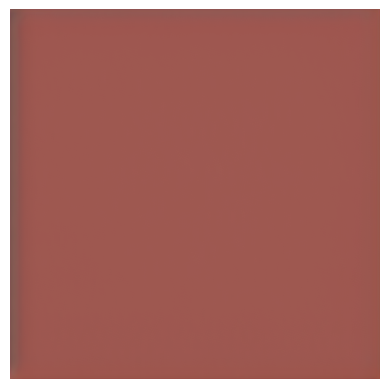

In [26]:
import matplotlib.pyplot as plt

plt.imshow(image[0])
plt.axis("off")
plt.show()

In [27]:
!pip install opencv-python matplotlib pillow numpy --quiet

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

In [29]:
# Download image
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
response = requests.get(url)

original = Image.open(BytesIO(response.content)).convert("RGB")
original = original.resize((512, 512))

# Convert to numpy array
original_np = np.array(original)

In [30]:
noise = np.random.normal(0, 25, original_np.shape)
noisy_image = original_np + noise
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

In [31]:
mean_filtered = cv2.blur(noisy_image, (5, 5))

In [32]:
median_filtered = cv2.medianBlur(noisy_image, 5)

In [33]:
gaussian_filtered = cv2.GaussianBlur(noisy_image, (5, 5), 0)

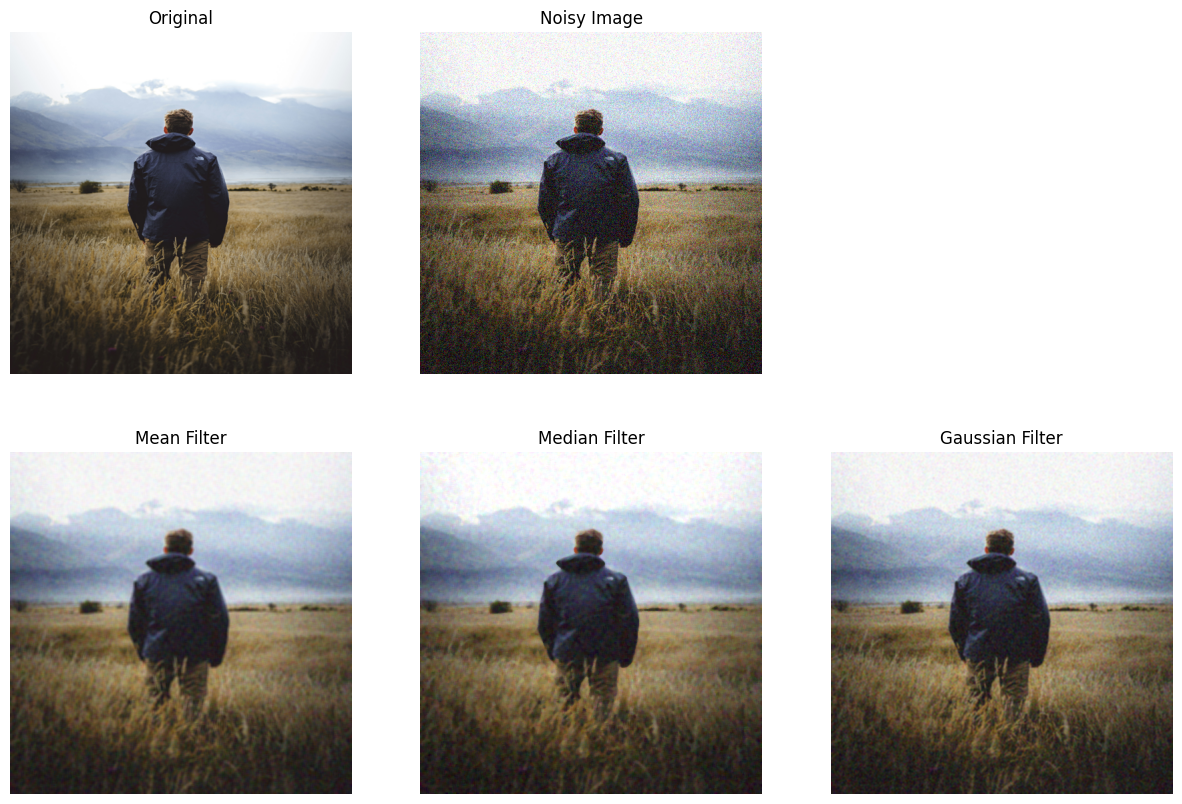

In [34]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(original_np)
plt.axis("off")

plt.subplot(2,3,2)
plt.title("Noisy Image")
plt.imshow(noisy_image)
plt.axis("off")

plt.subplot(2,3,4)
plt.title("Mean Filter")
plt.imshow(mean_filtered)
plt.axis("off")

plt.subplot(2,3,5)
plt.title("Median Filter")
plt.imshow(median_filtered)
plt.axis("off")

plt.subplot(2,3,6)
plt.title("Gaussian Filter")
plt.imshow(gaussian_filtered)
plt.axis("off")

plt.show()